# QEC Plot Notebook

This notebook is used to generate the main tables and figures for the paper from the simulation logs.

The four main experiment groups are:

1. Gate-fidelity sweep
   This compares `none`, `cec`, and `qec` while sweeping two-qubit gate fidelity, with one-qubit and measurement fidelity scaled accordingly. The goal is to identify the practical gate-fidelity threshold for each correction method.

2. Coherence-time sweep
   This compares `none`, `cec`, and `qec` while sweeping memory coherence time. The goal is to see how strongly each method depends on memory quality and where each approach begins to fail.

3. End-to-end distance sweep
   This keeps the elementary-link distance fixed at `10 km` and increases the total communication distance. The goal is to measure both latency and end-to-end fidelity as distance grows.

4. Link-count sweep
   This varies the number of links in the chain while keeping the elementary-link distance fixed at `10 km`. The goal is to study how end-to-end fidelity changes as the number of hops increases.


In [164]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


## Parse Logs

These regex patterns parse the log filenames and result lines.


In [165]:
line_re = re.compile(
    r"run_id=(?P<run_id>\d+), time to serve=(?P<latency>[-+0-9.eE]+), "
    r"(?:fidelity_raw=(?P<fidelity_raw>[-+0-9.eE]+), fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+), )?"
    r"fidelity=(?P<fidelity>[-+0-9.eE]+)"
)

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"(?:physbell=(?P<physbell>[0-9.]+|cfg),)?"
    r"ts=(?P<ts>\d{8}_\d{4})"
)

## Load Data

This function loads one log directory into a pandas dataframe.


In [166]:
def load_runner_logs(log_dir: Path) -> pd.DataFrame:
    """Load one runner log directory into a flat dataframe.

    Args:
        log_dir: Directory containing runner log files.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows = []
    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue
        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        log_mtime = path.stat().st_mtime
        nodes = int(meta["nodes"])
        num_links = nodes - 1
        elementary_link_km = float(meta["dist"])
        total_distance_km = num_links * elementary_link_km
        t2_value = float(meta["t2"])

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = line_re.search(line)
                if line_match is None:
                    continue
                rows.append({
                    "log_name": path.name,
                    "log_mtime": log_mtime,
                    "nodes": nodes,
                    "num_links": num_links,
                    "elementary_link_km": elementary_link_km,
                    "total_distance_km": total_distance_km,
                    "css_code": meta["code"],
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "gate_fidelity": float(meta["gate"]),
                    "state_preparation_fidelity": float(meta["prep"]),
                    "physical_bell_pair_fidelity": None if meta.get("physbell") in (None, "cfg") else float(meta["physbell"]),
                    "data_t2": t2_value,
                    "comm_t2": t2_value,
                    "t1": float(meta["t1"]),
                    "correction_mode": meta["ccorr"],
                    "ft_prep_mode": meta["ft"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ms": float(line_match["latency"]),
                    "fidelity": float(line_match["fidelity"]),
                    "fidelity_raw": float(line_match["fidelity_raw"]) if line_match["fidelity_raw"] is not None else float(line_match["fidelity"]),
                    "fidelity_corrected": float(line_match["fidelity_corrected"]) if line_match["fidelity_corrected"] is not None else float(line_match["fidelity"]),
                })
    return pd.DataFrame(rows)


# Experiments


In [167]:
run_after = None


In [168]:
output_dir = Path("/Users/patange/Documents/Argonne/QEC/plot_pngs")
output_dir.mkdir(parents=True, exist_ok=True)


## Qubit Overhead Table

Show total qubit overhead as a function of correction mode, FT preparation mode, and the number of nodes `n`.


In [169]:
n = 11  # Number of nodes in the linear chain.

qec_ancillas_by_mode = {"none": 0, "cec": 0, "qec": 3}
ft_ancillas_by_mode = {"none": 0, "minimal": 1, "standard": 4}

rows = []
for correction_mode, qec_ancillas in qec_ancillas_by_mode.items():
    for ft_prep_mode, ft_ancillas in ft_ancillas_by_mode.items():
        ancillas_per_end = max(qec_ancillas, ft_ancillas)
        comm_qubits_per_end = 7
        data_qubits_per_end = 7
        qubits_per_end = comm_qubits_per_end + data_qubits_per_end + ancillas_per_end
        total_qubits = 2 * (n - 1) * qubits_per_end
        rows.append({
            "n": n,
            "correction_mode": correction_mode,
            "ft_prep_mode": ft_prep_mode,
            "comm_qubits_per_end": comm_qubits_per_end,
            "data_qubits_per_end": data_qubits_per_end,
            "reserved_ancillas_per_end": ancillas_per_end,
            "qubits_per_end": qubits_per_end,
            "total_qubits": total_qubits,
        })

pd.DataFrame(rows).sort_values(["correction_mode", "ft_prep_mode"]).reset_index(drop=True)


,n,correction_mode,ft_prep_mode,comm_qubits_per_end,data_qubits_per_end,reserved_ancillas_per_end,qubits_per_end,total_qubits
0,11,cec,minimal,7,7,1,15,300
1,11,cec,none,7,7,0,14,280
2,11,cec,standard,7,7,4,18,360
3,11,none,minimal,7,7,1,15,300
4,11,none,none,7,7,0,14,280
5,11,none,standard,7,7,4,18,360
6,11,qec,minimal,7,7,3,17,340
7,11,qec,none,7,7,3,17,340
8,11,qec,standard,7,7,4,18,360


## Graph 1: Gate-Fidelity Sweep

Plot end-to-end fidelity versus two-qubit gate fidelity for `none`, `cec`, and `qec`.


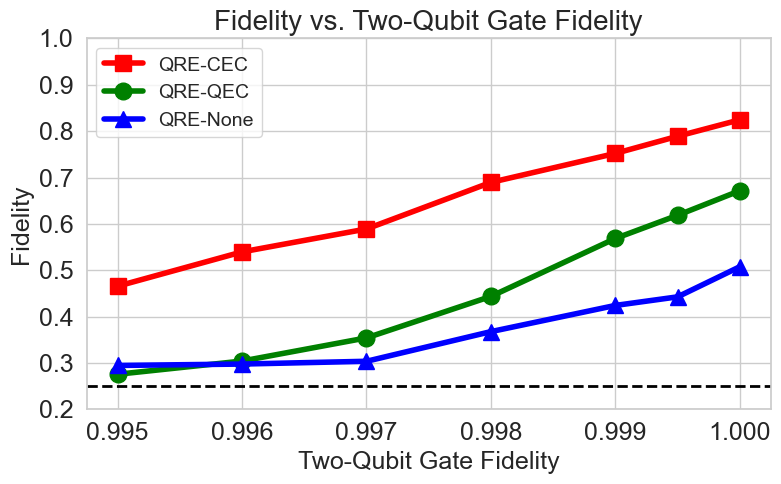

In [170]:
graph1_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph1_twoqubit_gate_sweep")
graph1_df = load_runner_logs(graph1_log_dir)

if graph1_df.empty:
    print("No Graph 1 data found.")
else:
    # Average all completed runs at each two-qubit fidelity and protocol setting.
    graph1_summary = graph1_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean")).sort_values(["two_qubit_gate_fidelity", "correction_mode"]).reset_index(drop=True)
    # Keep the protocol colors and display names local to this plot.
    colors = {"cec": "red", "none": "blue", "qec": "green"}
    names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
    markers = {"cec": "s", "none": "^", "qec": "o"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    # Draw each protocol separately so the marker shapes stay fixed.
    for protocol in ["cec", "qec", "none"]:
        data = graph1_summary[graph1_summary["correction_mode"] == protocol]
        ax.plot(data["two_qubit_gate_fidelity"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=f"{names[protocol]} (corrected)")
        ax.plot(data["two_qubit_gate_fidelity"], data["mean_fidelity_raw"], color=colors[protocol], linewidth=3, linestyle="--", label=f"{names[protocol]} (raw)")
    ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity", fontsize=20)
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_ylim(0.2, 1.0)
    ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.tick_params(axis="both", labelsize=18)
    ax.legend(fontsize=14, loc="upper left")
    plt.tight_layout()
    plt.savefig(output_dir / "fidelity_vs_two_qubit_gate_fidelity.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph1_summary


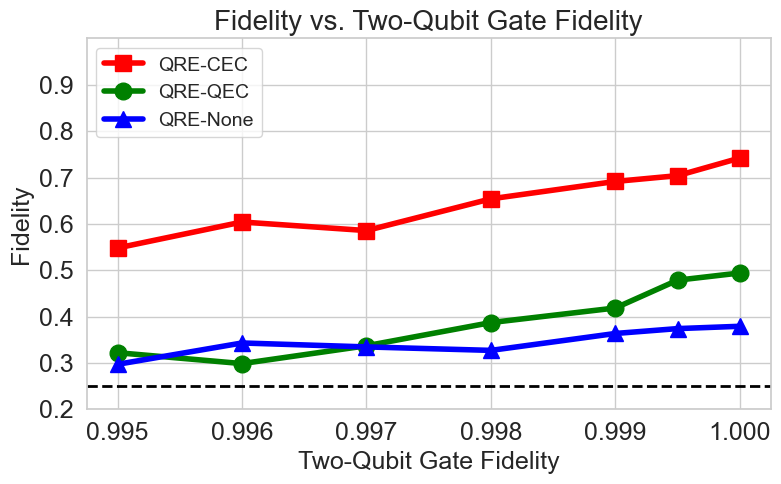

,two_qubit_gate_fidelity,correction_mode,mean_fidelity
0,0.9950,cec,0.5480
1,0.9950,none,0.2970
2,0.9950,qec,0.3220
3,0.9960,cec,0.6040
4,0.9960,none,0.3430
5,0.9960,qec,0.2985
6,0.9970,cec,0.5855
7,0.9970,none,0.3345
8,0.9970,qec,0.3370
9,0.9980,cec,0.6540


In [171]:
graph1_runner2_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner2/graph1_twoqubit_gate_sweep")
graph1_runner2_df = load_runner_logs(graph1_runner2_log_dir)

# Average all completed runs at each two-qubit fidelity and protocol setting.
graph1_runner2_summary = graph1_runner2_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean")).sort_values(["two_qubit_gate_fidelity", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

plt.figure(figsize=(8, 5))
ax = plt.gca()

for protocol in ["cec", "qec", "none"]:
    data = graph1_runner2_summary[graph1_runner2_summary["correction_mode"] == protocol]

    ax.plot(data["two_qubit_gate_fidelity"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=f"{names[protocol]} (corrected)")
    ax.plot(data["two_qubit_gate_fidelity"], data["mean_fidelity_raw"], color=colors[protocol], linewidth=3, linestyle="--", label=f"{names[protocol]} (raw)")

ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
ax.set_ylabel("Fidelity", fontsize=18)
ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity", fontsize=20)
ax.set_ylim(0.2, 1.0)
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ax.tick_params(axis="both", labelsize=18)
ax.legend(fontsize=14, loc="upper left")

plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_two_qubit_gate_fidelity_runner2.png", dpi=300, bbox_inches="tight")
plt.show()

graph1_runner2_summary


## Graph 2: Coherence-Time Sweep

Plot end-to-end fidelity versus coherence time for `none`, `cec`, and `qec`.


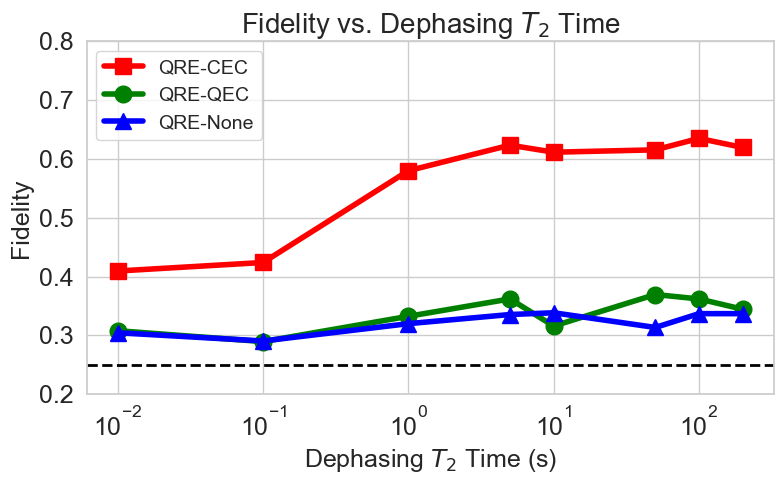

In [172]:
graph2_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph2_t2_sweep")
graph2_df = load_runner_logs(graph2_log_dir)


# Average all completed runs at each T2 value and protocol setting.
graph2_summary = graph2_df.groupby(["data_t2", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean")).sort_values(["data_t2", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

plt.figure(figsize=(8, 5))
ax = plt.gca()
# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "qec", "none"]:
    data = graph2_summary[graph2_summary["correction_mode"] == protocol]
    ax.plot(data["data_t2"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=f"{names[protocol]} (corrected)")
    ax.plot(data["data_t2"], data["mean_fidelity_raw"], color=colors[protocol], linewidth=3, linestyle="--", label=f"{names[protocol]} (raw)")
ax.set_xscale("log")
ax.set_xlabel("Dephasing $T_2$ Time (s)", fontsize=18)
ax.set_ylabel("Fidelity", fontsize=18)
ax.set_title("Fidelity vs. Dephasing $T_2$ Time", fontsize=20)
ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax.set_ylim(0.2, 0.8)
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
ax.tick_params(axis="both", labelsize=18)
ax.legend(fontsize=14, loc="upper left")
plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_coherence_time.png", dpi=300, bbox_inches="tight")
plt.show()


## Graph 3: End-to-End Distance Sweep

Plot both latency and end-to-end fidelity versus total distance, with `10 km` elementary links.


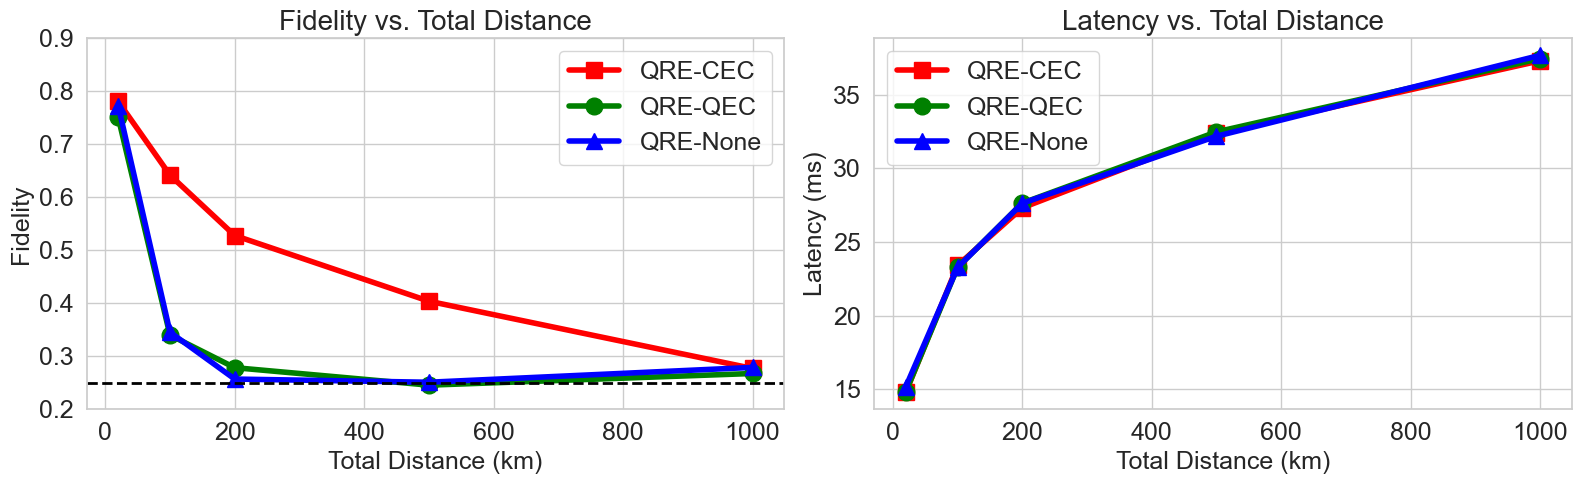

In [173]:
graph3_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph3_distance_sweep")
graph3_df = load_runner_logs(graph3_log_dir)


# Build one table with the mean latency and fidelity at each distance and protocol.
graph3_summary = graph3_df.groupby(["total_distance_km", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean"), mean_latency_ms=("latency_ms", "mean")).sort_values(["total_distance_km", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Left panel: latency.
ax0 = axes[1]
# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "qec", "none"]:
    data = graph3_summary[(graph3_summary["correction_mode"] == protocol) & (graph3_summary["total_distance_km"] != 2000)]
    ax0.plot(data["total_distance_km"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
ax0.set_xlabel("Total Distance (km)", fontsize=18)
ax0.set_ylabel("Latency (ms)", fontsize=18)
ax0.set_title("Latency vs. Total Distance", fontsize=20)
ax0.tick_params(axis="both", labelsize=18)

# Right panel: fidelity.
ax1 = axes[0]
for protocol in ["cec", "qec", "none"]:
    data = graph3_summary[(graph3_summary["correction_mode"] == protocol) & (graph3_summary["total_distance_km"] != 2000)]
    ax1.plot(data["total_distance_km"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=f"{names[protocol]} (corrected)")
    ax1.plot(data["total_distance_km"], data["mean_fidelity_raw"], color=colors[protocol], linewidth=3, linestyle="--", label=f"{names[protocol]} (raw)")
ax1.set_xlabel("Total Distance (km)", fontsize=18)
ax1.set_ylabel("Fidelity", fontsize=18)
ax1.set_title("Fidelity vs. Total Distance", fontsize=20)
ax1.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax1.set_ylim(0.2, 0.9)
ax1.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ax1.tick_params(axis="both", labelsize=18)

ax0.legend(fontsize=18)
ax1.legend(fontsize=18)

plt.tight_layout()
plt.savefig(output_dir / "distance_sweep_varryingNodes.png", dpi=300, bbox_inches="tight")
plt.show()


## Graph 4: Link-Count Sweep

Plot end-to-end fidelity versus number of links, with `10 km` elementary links.


/var/folders/pz/qmtxblt536z17q2qg96mb3740000gn/T/ipykernel_25451/2374942058.py:40: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(bottom=0, top=5000)  # Set a minimum y-value to avoid issues with log scale.


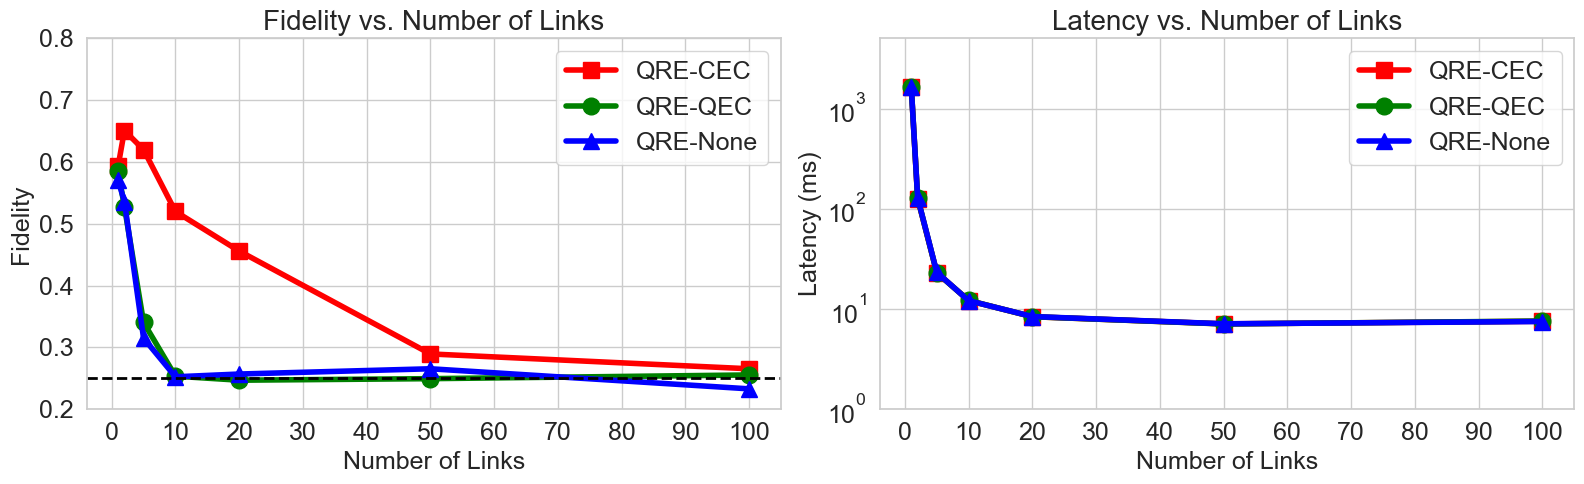

In [174]:
graph4_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph4_link_count_sweep")
graph4_df = load_runner_logs(graph4_log_dir)

if graph4_df.empty:
    print("No Graph 4 data found.")
else:
    # Average all completed runs at each link count and protocol setting.
    graph4_summary = graph4_df.groupby(["num_links", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean"), mean_latency_ms=("latency_ms", "mean")).sort_values(["num_links", "correction_mode"]).reset_index(drop=True)
    colors = {"cec": "red", "none": "blue", "qec": "green"}
    names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
    markers = {"cec": "s", "none": "^", "qec": "o"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    # Left panel: fidelity.
    ax0 = axes[0]
    # Draw each protocol separately so the marker shapes stay fixed.
    for protocol in ["cec", "qec", "none"]:
        data = graph4_summary[graph4_summary["correction_mode"] == protocol]
        ax0.plot(data["num_links"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=f"{names[protocol]} (corrected)")
        ax0.plot(data["num_links"], data["mean_fidelity_raw"], color=colors[protocol], linewidth=3, linestyle="--", label=f"{names[protocol]} (raw)")
    ax0.set_xlabel("Number of Links", fontsize=18)
    ax0.set_ylabel("Fidelity", fontsize=18)
    ax0.set_title("Fidelity vs. Number of Links", fontsize=20)
    ax0.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax0.set_ylim(0.2, 0.8)
    ax0.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
    ax0.set_xticks([0,10,20,30,40,50,60,70,80,90,100])

    ax0.tick_params(axis="both", labelsize=18)

    # Right panel: latency.
    ax1 = axes[1]
    for protocol in ["cec", "qec", "none"]:
        data = graph4_summary[graph4_summary["correction_mode"] == protocol]
        ax1.plot(data["num_links"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
    ax1.set_xlabel("Number of Links", fontsize=18)
    ax1.set_ylabel("Latency (ms)", fontsize=18)
    ax1.set_title("Latency vs. Number of Links", fontsize=20)
    ax1.set_yscale("log")
    # ax1.set_xscale("log")
    ax1.set_ylim(bottom=0, top=5000)  # Set a minimum y-value to avoid issues with log scale.
    ax1.tick_params(axis="both", labelsize=18)
    ax1.set_yticks([1,10, 100, 1000,])
    ax1.set_xticks([0,10,20,30,40,50,60,70,80,90,100])

    ax0.legend(fontsize=18)
    ax1.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(output_dir / "number_of_links_sweep_E2E100km.png", dpi=300, bbox_inches="tight")
    plt.show()


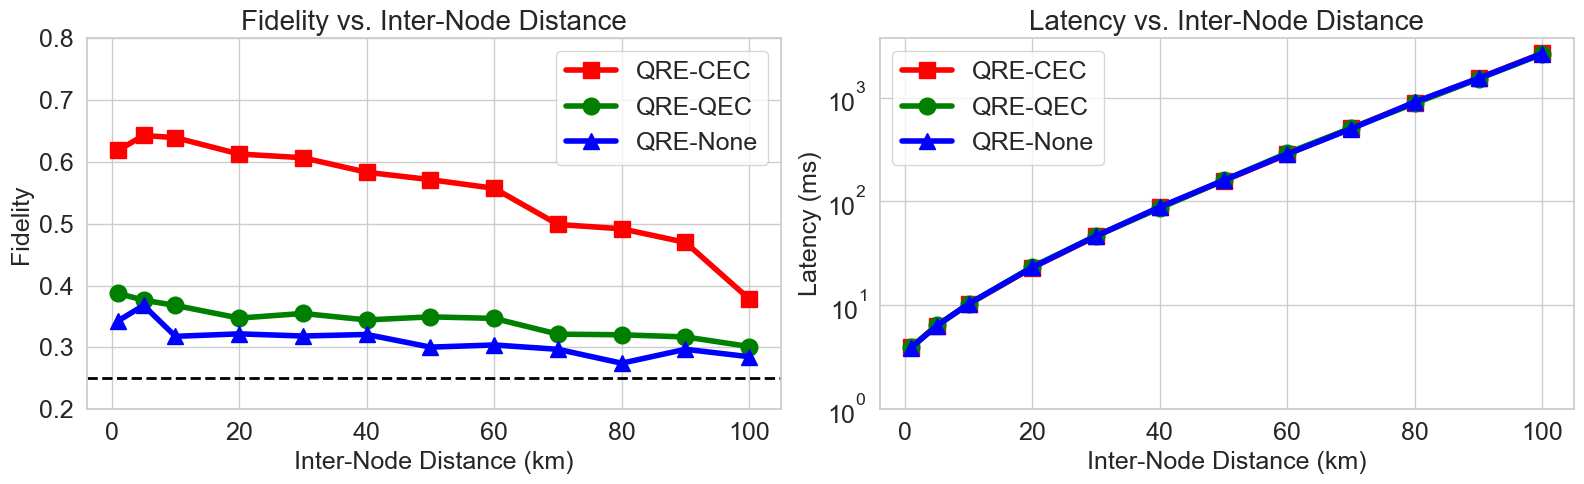

,elementary_link_km,correction_mode,mean_fidelity,mean_latency_ms
0,1.0,cec,0.619000,3.948488
1,1.0,none,0.343000,3.922049
2,1.0,qec,0.387500,3.969229
3,5.0,cec,0.643000,6.394489
4,5.0,none,0.368000,6.353995
5,5.0,qec,0.376500,6.421369
6,10.0,cec,0.639500,10.265122
7,10.0,none,0.318000,10.380838
8,10.0,qec,0.368000,10.269546
9,20.0,cec,0.613000,23.037333


In [175]:
graph5_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph5_inter_node_distance_sweep")
graph5_df = load_runner_logs(graph5_log_dir)

# Average all completed runs at each inter-node distance and protocol setting.
graph5_summary = graph5_df.groupby(["elementary_link_km", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean"), mean_latency_ms=("latency_ms", "mean")).sort_values(["elementary_link_km", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

for protocol in ["cec", "qec", "none"]:
    data = graph5_summary[(graph5_summary["correction_mode"] == protocol) & (~graph5_summary["elementary_link_km"].isin([2.5, 7.5, 110,120]))]
    axes[0].plot(data["elementary_link_km"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=f"{names[protocol]} (corrected)")
    axes[0].plot(data["elementary_link_km"], data["mean_fidelity_raw"], color=colors[protocol], linewidth=3, linestyle="--", label=f"{names[protocol]} (raw)")
    axes[1].plot(data["elementary_link_km"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

axes[0].set_xlabel("Inter-Node Distance (km)", fontsize=18)
axes[0].set_ylabel("Fidelity", fontsize=18)
axes[0].set_title("Fidelity vs. Inter-Node Distance", fontsize=20)
axes[0].axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
axes[0].set_ylim(0.2, 0.8)
axes[0].set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
axes[0].tick_params(axis="both", labelsize=18)
axes[0].legend(fontsize=18)

axes[1].set_xlabel("Inter-Node Distance (km)", fontsize=18)
axes[1].set_ylabel("Latency (ms)", fontsize=18)
axes[1].set_title("Latency vs. Inter-Node Distance", fontsize=20)
axes[1].tick_params(axis="both", labelsize=18)
axes[1].legend(fontsize=18)
axes[1].set_yscale("log")
axes[1].set_yticks([1e0, 1e1, 1e2, 1e3])


plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_inter_node_distance_5linktopology.png", dpi=300, bbox_inches="tight")
plt.show()

graph5_summary


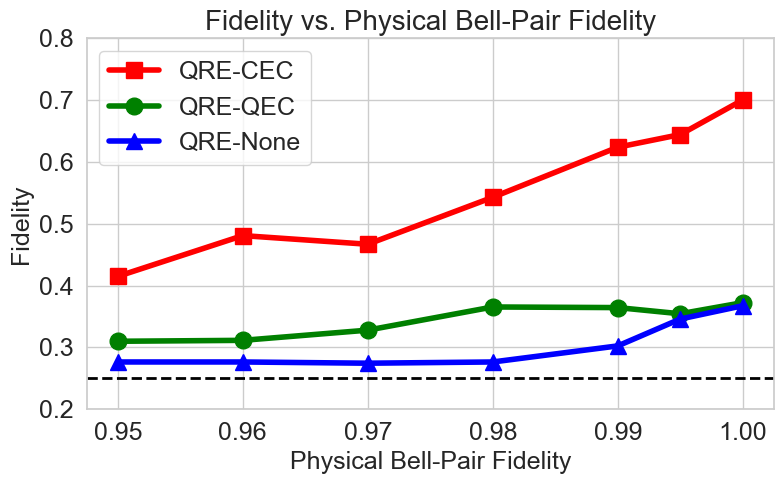

,physical_bell_pair_fidelity,correction_mode,mean_fidelity
0,0.950,cec,0.4150
1,0.950,none,0.2765
2,0.950,qec,0.3100
3,0.960,cec,0.4810
4,0.960,none,0.2765
5,0.960,qec,0.3115
6,0.970,cec,0.4670
7,0.970,none,0.2745
8,0.970,qec,0.3280
9,0.980,cec,0.5430


In [176]:
graph6_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph6_physical_bell_pair_fidelity_sweep")
graph6_df = load_runner_logs(graph6_log_dir)

# Average all completed runs at each physical Bell-pair fidelity and protocol setting.
graph6_summary = graph6_df.groupby(["physical_bell_pair_fidelity", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean")).sort_values(["physical_bell_pair_fidelity", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

plt.figure(figsize=(8, 5))
ax = plt.gca()

# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "qec", "none"]:
    data = graph6_summary[graph6_summary["correction_mode"] == protocol]
    ax.plot(data["physical_bell_pair_fidelity"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=f"{names[protocol]} (corrected)")
    ax.plot(data["physical_bell_pair_fidelity"], data["mean_fidelity_raw"], color=colors[protocol], linewidth=3, linestyle="--", label=f"{names[protocol]} (raw)")

ax.set_xlabel("Physical Bell-Pair Fidelity", fontsize=18)
ax.set_ylabel("Fidelity", fontsize=18)
ax.set_title("Fidelity vs. Physical Bell-Pair Fidelity", fontsize=20)
ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax.set_ylim(0.2, 0.8)
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
ax.tick_params(axis="both", labelsize=18)
ax.legend(fontsize=18)

plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_physical_bell_pair_fidelity.png", dpi=300, bbox_inches="tight")
plt.show()

graph6_summary


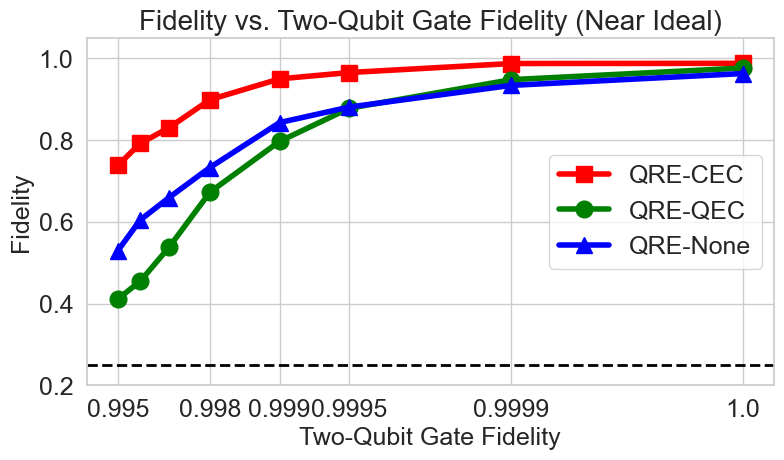

,two_qubit_gate_fidelity,correction_mode,mean_fidelity,two_qubit_gate_infidelity,two_qubit_gate_infidelity_plot
0,0.9950,cec,0.7380,0.0050,0.00500
1,0.9950,none,0.5290,0.0050,0.00500
2,0.9950,qec,0.4110,0.0050,0.00500
3,0.9960,cec,0.7920,0.0040,0.00400
4,0.9960,none,0.6045,0.0040,0.00400
5,0.9960,qec,0.4545,0.0040,0.00400
6,0.9970,cec,0.8305,0.0030,0.00300
7,0.9970,none,0.6595,0.0030,0.00300
8,0.9970,qec,0.5380,0.0030,0.00300
9,0.9980,cec,0.8990,0.0020,0.00200


In [177]:
graph7_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph7_twoqubit_gate_fidelity_sweep_nice_params")
graph7_df = load_runner_logs(graph7_log_dir)

# Average all completed runs at each two-qubit gate fidelity and protocol setting.
graph7_summary = graph7_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean")).sort_values(["two_qubit_gate_fidelity", "correction_mode"]).reset_index(drop=True)
graph7_summary["two_qubit_gate_infidelity"] = 1.0 - graph7_summary["two_qubit_gate_fidelity"]
graph7_summary["two_qubit_gate_infidelity_plot"] = graph7_summary["two_qubit_gate_infidelity"].replace(0.0, 1e-5)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

plt.figure(figsize=(8, 5))
ax = plt.gca()

# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "qec", "none"]:
    data = graph7_summary[graph7_summary["correction_mode"] == protocol]
    ax.plot(data["two_qubit_gate_infidelity_plot"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=f"{names[protocol]} (corrected)")
    ax.plot(data["two_qubit_gate_infidelity_plot"], data["mean_fidelity_raw"], color=colors[protocol], linewidth=3, linestyle="--", label=f"{names[protocol]} (raw)")

ax.set_xscale("log")
ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
ax.set_ylabel("Fidelity", fontsize=18)
ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity (Near Ideal)", fontsize=20)
# ax.text(0.5, 1.01, "1Q Gate Fidelity = Measurement Fidelity = 0.9999, $T_1$ = $T_2$ = 100s, \n Physical Bell Pair Fidelity = 0.9999, Prep Fidelity = 0.99999", transform=ax.transAxes, ha="center", va="bottom", fontsize=9)
ax.set_ylim(0.2, 1.05)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis="y", labelsize=18)
ax.tick_params(axis="x", labelsize=18)
ax.legend(fontsize=18)

tick_fidelities = [0.995, 0.998, 0.999, 0.9995, 0.9999, 1.0]
tick_positions = [1.0 - value if value < 1.0 else 1e-5 for value in tick_fidelities]
ax.set_xticks(tick_positions)
ax.set_xticklabels(["0.995", "0.998", "0.999", "0.9995", "0.9999", "1.0"])
ax.invert_xaxis()

plt.tight_layout()
plt.subplots_adjust(top=0.86)
plt.savefig(output_dir / "fidelity_vs_two_qubit_gate_fidelity_nice_params.png", dpi=300, bbox_inches="tight")
plt.show()

graph7_summary


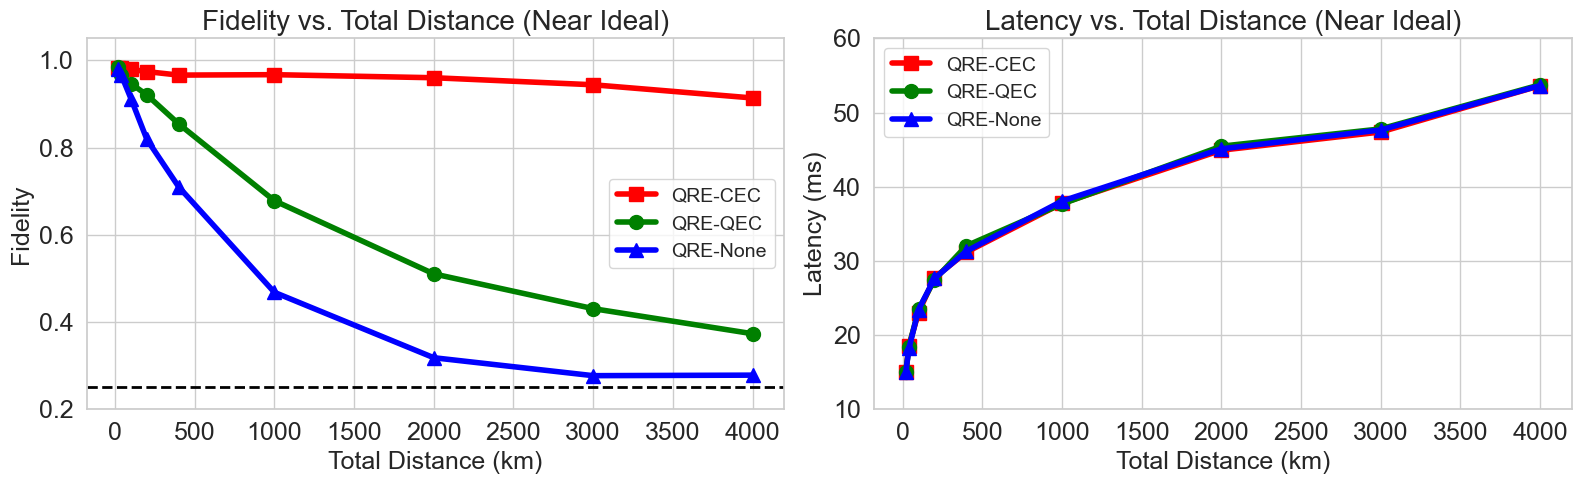

,total_distance_km,correction_mode,mean_fidelity,mean_latency_ms
0,20.0,cec,0.981500,14.991939
1,20.0,none,0.979000,15.017614
2,20.0,qec,0.983500,14.966616
3,40.0,cec,0.981500,18.571625
4,40.0,none,0.965500,18.218646
5,40.0,qec,0.966000,18.431758
6,100.0,cec,0.979000,23.046360
7,100.0,none,0.912000,23.420495
8,100.0,qec,0.946500,23.454712
9,200.0,cec,0.974000,27.744735


In [178]:
graph8_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph8_ideal_params_distance_sweep")
graph8_df = load_runner_logs(graph8_log_dir)

graph8_summary = (
    graph8_df.groupby(["total_distance_km", "correction_mode"], as_index=False)
    .agg(
        mean_fidelity_raw=("fidelity_raw", "mean"),
        mean_fidelity_corrected=("fidelity_corrected", "mean"),
        mean_latency_ms=("latency_ms", "mean"),
    )
    .sort_values(["total_distance_km", "correction_mode"])
    .reset_index(drop=True)
)

colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for protocol in ["cec", "qec", "none"]:
    data = graph8_summary[graph8_summary["correction_mode"] == protocol]
    axes[0].plot(
        data["total_distance_km"],
        data["mean_fidelity_corrected"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        linestyle="-",
        label=f"{names[protocol]} (corrected)",
    )
    axes[0].plot(
        data["total_distance_km"],
        data["mean_fidelity_raw"],
        color=colors[protocol],
        linewidth=3,
        linestyle="--",
        label=f"{names[protocol]} (raw)",
    )
    axes[1].plot(
        data["total_distance_km"],
        data["mean_latency_ms"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )

axes[0].axhline(0.25, color="black", linestyle="--", linewidth=2)
axes[0].set_xlabel("Total Distance (km)", fontsize=18)
axes[0].set_ylabel("Fidelity", fontsize=18)
axes[0].set_title("Fidelity vs. Total Distance (Near Ideal)", fontsize=20)
axes[0].set_ylim(0.2, 1.05)
axes[0].tick_params(axis="both", labelsize=18)
axes[0].legend(fontsize=14)

axes[1].set_xlabel("Total Distance (km)", fontsize=18)
axes[1].set_ylabel("Latency (ms)", fontsize=18)
axes[1].set_title("Latency vs. Total Distance (Near Ideal)", fontsize=20)
axes[1].tick_params(axis="both", labelsize=18)
axes[1].legend(fontsize=14)
axes[1].set_yticks([10,20, 30,40,50,60])

plt.tight_layout()
plt.savefig(output_dir / "distance_sweep_ideal_params_20km.png", dpi=300, bbox_inches="tight")
plt.show()

graph8_summary


## Resource Counting Model

For a line topology with:
- \(N\) nodes
- \(L = N - 1\) links
- \(I = N - 2\) intermediate nodes

we estimate the static resource cost of one completed end-to-end logical pair for the \([[7,1,3]]\) code in `none` / `cec` mode by splitting the protocol into three phases:

### 1. Logical Block Preparation

Each logical block contributes:
- \(11\) two-qubit gates
- \(3\) one-qubit gates
- \(1\) measurement

There are \(2N - 2\) logical blocks total, and the right-facing \(|+_L\rangle\)-type blocks add \(7\) extra one-qubit gates per link.

So preparation contributes:

\[
\text{2Q} = 11(2N - 2) = 22N - 22
\]

\[
\text{1Q} = 3(2N - 2) + 7(N - 1) = 13N - 13
\]

\[
\text{M} = 2N - 2
\]

### 2. Teleported CNOTs Across Links

Per link, the teleported CNOT contributes:
- \(14\) two-qubit gates
- \(21\) one-qubit gates
- \(14\) measurements

Across all \(L = N - 1\) links:

\[
\text{2Q} = 14(N - 1) = 14N - 14
\]

\[
\text{1Q} = 21(N - 1) = 21N - 21
\]

\[
\text{M} = 14(N - 1) = 14N - 14
\]

### 3. QRE Swaps at Intermediate Nodes

Per intermediate node, the swap contributes:
- \(7\) two-qubit gates
- \(7\) one-qubit gates
- \(14\) measurements

Across all \(I = N - 2\) intermediate nodes:

\[
\text{2Q} = 7(N - 2) = 7N - 14
\]

\[
\text{1Q} = 7(N - 2) = 7N - 14
\]

\[
\text{M} = 14(N - 2) = 14N - 28
\]

### 4. Final Frame Cleanup

We include a constant budget of \(28\) one-qubit corrections for endpoint frame cleanup.

### Final Static Counts for `cec` / `none`

Adding the three phases and the final cleanup term gives:

\[
\text{Two-Qubit Gates} = (22N - 22) + (14N - 14) + (7N - 14) = 43N - 50
\]

\[
\text{One-Qubit Gates} = (13N - 13) + (21N - 21) + (7N - 14) + 28 = 41N - 20
\]

\[
\text{Measurements} = (2N - 2) + (14N - 14) + (14N - 28) = 30N - 44
\]

### Qubit Overhead

We use the encoded data-block qubit count:

\[
\text{Qubits} = 14(N - 1)
\]

since each link carries two logical blocks of \(7\) physical qubits each.

### Extra `qec` Overhead

For `qec`, each intermediate node adds two Steane-style QEC rounds, which contribute:

- \(48\) extra two-qubit gates per intermediate node
- \(14\) extra one-qubit gates per intermediate node
- \(12\) extra measurements per intermediate node

So for `qec`:

\[
\text{Two-Qubit Gates} = (43N - 50) + 48(N - 2)
\]

\[
\text{One-Qubit Gates} = (41N - 20) + 14(N - 2)
\]

\[
\text{Measurements} = (30N - 44) + 12(N - 2)
\]


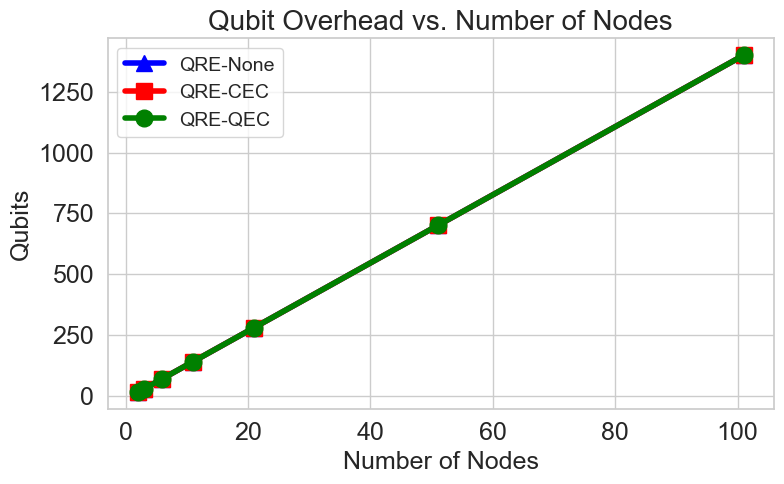

In [179]:
def count_resources(num_nodes: int, correction_mode: str) -> dict[str, int]:
    """Compute analytic resource counts for one end-to-end logical pair.

    Args:
        num_nodes: Number of nodes in the line topology.
        correction_mode: Correction mode name.

    Returns:
        dict[str, int]: Counts for qubits, two-qubit gates, one-qubit gates, and measurements.
    """
    num_links = num_nodes - 1
    num_intermediate_nodes = num_nodes - 2

    qubits = 14 * num_links
    two_qubit_gates = 43 * num_nodes - 50
    one_qubit_gates = 41 * num_nodes - 20
    measurements = 30 * num_nodes - 44

    if correction_mode == "qec":
        two_qubit_gates += 48 * num_intermediate_nodes
        one_qubit_gates += 14 * num_intermediate_nodes
        measurements += 12 * num_intermediate_nodes

    return {
        "num_nodes": num_nodes,
        "correction_mode": correction_mode,
        "qubits": qubits,
        "two_qubit_gates": two_qubit_gates,
        "one_qubit_gates": one_qubit_gates,
        "measurements": measurements,
    }


node_counts = [2, 3, 6, 11, 21, 51, 101]
rows = []
for num_nodes in node_counts:
    rows.append(count_resources(num_nodes, "none"))
    rows.append(count_resources(num_nodes, "cec"))
    rows.append(count_resources(num_nodes, "qec"))

resource_df = pd.DataFrame(rows)
colors = {"none": "blue", "cec": "red", "qec": "green"}
names = {"none": "QRE-None", "cec": "QRE-CEC", "qec": "QRE-QEC"}
markers = {"none": "^", "cec": "s", "qec": "o"}

plt.figure(figsize=(8, 5))
ax = plt.gca()

for protocol in ["none", "cec", "qec"]:
    data = resource_df[resource_df["correction_mode"] == protocol]
    ax.plot(data["num_nodes"], data["qubits"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

ax.set_title("Qubit Overhead vs. Number of Nodes", fontsize=20)
ax.set_xlabel("Number of Nodes", fontsize=18)
ax.set_ylabel("Qubits", fontsize=18)
ax.tick_params(axis="both", labelsize=18)
ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig(output_dir / "qubit_overhead_vs_number_of_nodes.png", dpi=300, bbox_inches="tight")
plt.show()


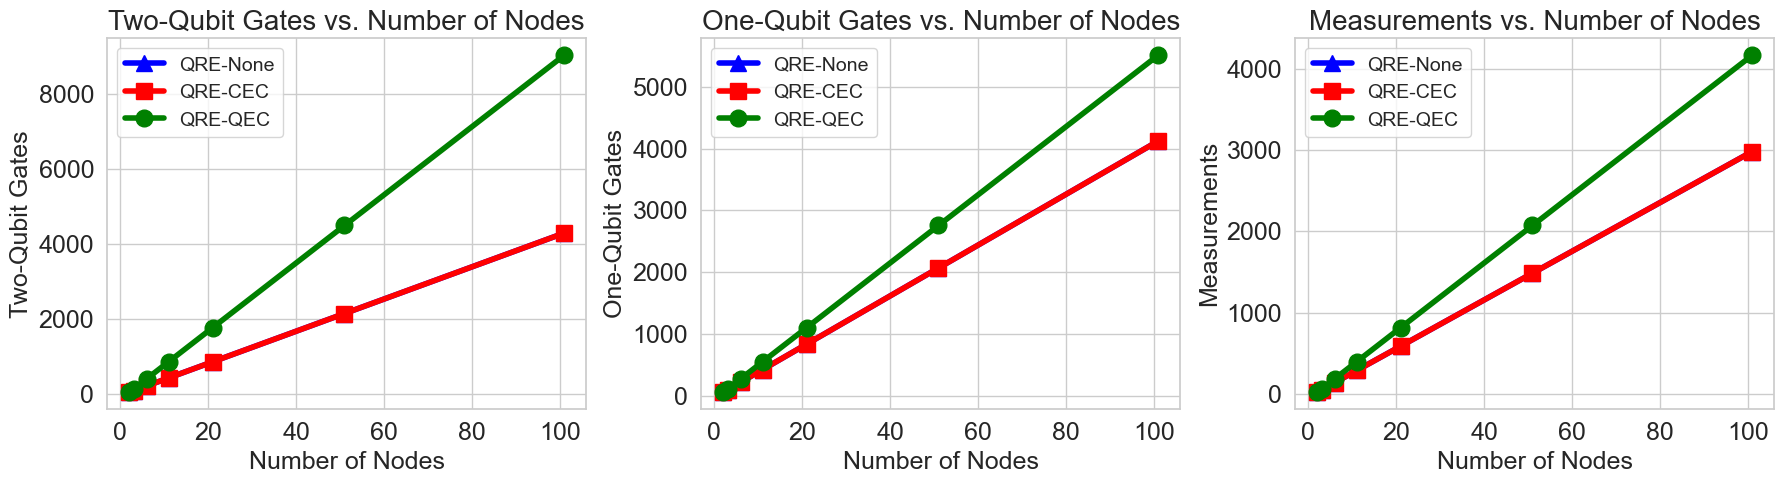

,num_nodes,correction_mode,qubits,two_qubit_gates,one_qubit_gates,measurements
0,2,none,14,36,62,16
1,2,cec,14,36,62,16
2,2,qec,14,36,62,16
3,3,none,28,79,103,46
4,3,cec,28,79,103,46
5,3,qec,28,127,117,58
6,6,none,70,208,226,136
7,6,cec,70,208,226,136
8,6,qec,70,400,282,184
9,11,none,140,423,431,286


In [180]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {"none": "blue", "cec": "red", "qec": "green"}
names = {"none": "QRE-None", "cec": "QRE-CEC", "qec": "QRE-QEC"}
markers = {"none": "^", "cec": "s", "qec": "o"}

for protocol in ["none", "cec", "qec"]:
    data = resource_df[resource_df["correction_mode"] == protocol]
    axes[0].plot(data["num_nodes"], data["two_qubit_gates"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
    axes[1].plot(data["num_nodes"], data["one_qubit_gates"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
    axes[2].plot(data["num_nodes"], data["measurements"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

axes[0].set_title("Two-Qubit Gates vs. Number of Nodes", fontsize=20)
axes[0].set_xlabel("Number of Nodes", fontsize=18)
axes[0].set_ylabel("Two-Qubit Gates", fontsize=18)
axes[0].tick_params(axis="both", labelsize=18)
axes[0].legend(fontsize=14)

axes[1].set_title("One-Qubit Gates vs. Number of Nodes", fontsize=20)
axes[1].set_xlabel("Number of Nodes", fontsize=18)
axes[1].set_ylabel("One-Qubit Gates", fontsize=18)
axes[1].tick_params(axis="both", labelsize=18)
axes[1].legend(fontsize=14)

axes[2].set_title("Measurements vs. Number of Nodes", fontsize=20)
axes[2].set_xlabel("Number of Nodes", fontsize=18)
axes[2].set_ylabel("Measurements", fontsize=18)
axes[2].tick_params(axis="both", labelsize=18)
axes[2].legend(fontsize=14)

plt.tight_layout()
plt.savefig(output_dir / "operations_vs_number_of_nodes.png", dpi=300, bbox_inches="tight")
plt.show()

resource_df


In [181]:
import stim

# Create a Tableau simulator
sim = stim.TableauSimulator()

# Prepare |Psi+> = (|00> + |11>) / sqrt(2)
# Start from |00>, apply H to qubit 0, then CNOT(0,1)
sim.h(0)
sim.cnot(0, 1)

# Print the current stabilizer tableau
tableau = sim.current_inverse_tableau()**-1
print("Stabilizer tableau for |Psi+>:")
print(tableau)

Stabilizer tableau for |Psi+>:
+-xz-xz-
| ++ ++
| ZX _Z
| _X XZ
